EVALUASI MODEL RANDOM FOREST

Model berhasil dibaca.

HASIL EVALUASI
Accuracy  : 0.9996
Precision : 0.8842
Recall    : 0.8571
F1 Score  : 0.8705
ROC AUC   : 0.9634

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.86      0.87        98

    accuracy                           1.00     56962
   macro avg       0.94      0.93      0.94     56962
weighted avg       1.00      1.00      1.00     56962



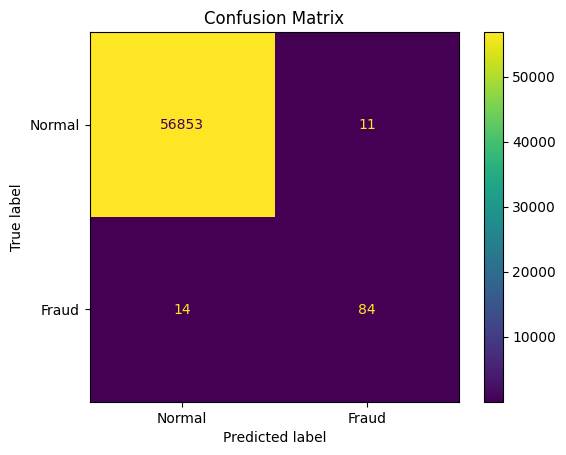

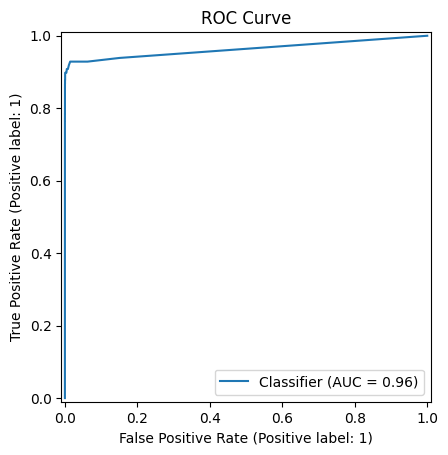


10 Feature Terpenting
                         Feature  Importance
14    Faktor Anomali Transaksi A    0.198521
10        Sensor Pola Kecurangan    0.111963
4           Pola Jejak Digital B    0.103327
12    Faktor Anomali Transaksi B    0.095209
17  Indikator Utama Penyimpangan    0.078749
3        Profiling Nasabah Gen-3    0.062516
11       Parameter Risiko Sistem    0.055619
16     Skor Integritas Transaksi    0.044193
2        Profiling Nasabah Gen-2    0.037347
9           Pola Jejak Digital A    0.025645


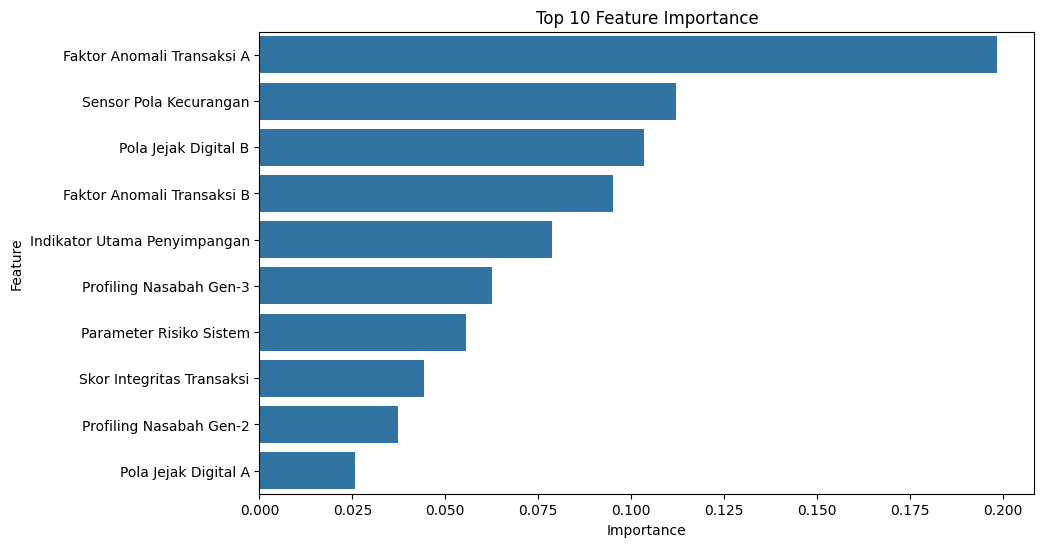


Evaluasi selesai.


In [1]:
# ==========================================================
# PROJECT MACHINE LEARNING
# CREDIT CARD FRAUD DETECTION
# TAHAP 4 : EVALUASI MODEL RANDOM FOREST
# ==========================================================

# ===========================
# Import Library
# ===========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score,
    classification_report
)

# ===========================
# Load Dataset
# ===========================

print("="*60)
print("EVALUASI MODEL RANDOM FOREST")
print("="*60)

df = pd.read_csv("dataset/creditcard.csv")

X = df.drop("Class", axis=1)

y = df["Class"]

# ===========================
# Train Test Split
# ===========================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

# ===========================
# Scaling
# ===========================

scaler = joblib.load("model/scaler.pkl")

X_test = scaler.transform(X_test)

# ===========================
# Load Model
# ===========================

model = joblib.load("model/random_forest_model.pkl")

print("\nModel berhasil dibaca.")

# ===========================
# Prediksi
# ===========================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

# ===========================
# Accuracy
# ===========================

accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(y_test,y_pred)

recall = recall_score(y_test,y_pred)

f1 = f1_score(y_test,y_pred)

roc = roc_auc_score(y_test,y_prob)

print("\n==============================")

print("HASIL EVALUASI")

print("==============================")

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

print(f"ROC AUC   : {roc:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test,y_pred))

# ===========================
# Confusion Matrix
# ===========================

cm = confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Normal","Fraud"]

)

disp.plot()

plt.title("Confusion Matrix")

plt.savefig("images/confusion_matrix.png")

plt.show()

# ===========================
# ROC Curve
# ===========================

RocCurveDisplay.from_predictions(

    y_test,

    y_prob

)

plt.title("ROC Curve")

plt.savefig("images/roc_curve.png")

plt.show()

# ===========================
# Feature Importance
# ===========================

importance = model.feature_importances_

feature = X.columns

importance_df = pd.DataFrame({

    "Feature":feature,

    "Importance":importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

print("\n10 Feature Terpenting")

print(importance_df.head(10))

plt.figure(figsize=(10,6))

sns.barplot(

    data=importance_df.head(10),

    x="Importance",

    y="Feature"

)

plt.title("Top 10 Feature Importance")

plt.savefig("images/feature_importance.png")

plt.show()

print("\nEvaluasi selesai.")

print("="*60)